<a href="https://colab.research.google.com/github/sara010896/PPCA_UnB/blob/main/Lista_1_solucao_Sara_Borges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lista 1: geração de números pseudo-aleatórios
### Prof. Guilherme Rodrigues
#### Métodos Computacionais Intensivos para Mineração de Dados
#### Aluno(a): Sara Borges Lopes de Sousa
####Matrícula: 212507073

# Lista 1: Geração de números pseudo-aleatórios
##Importação de Bibliotecas

Configuração inicial do ambiente de análise em Python, incluindo a importação das bibliotecas necessárias, a personalização dos parâmetros gráficos do Matplotlib e a definição de uma semente (seed) global para garantir a reprodutibilidade dos resultados.

> Pré-requisitos: `numpy`, `matplotlib`. O arquivo `Dicionario.txt` deve estar no mesmo diretório.

In [4]:
import os, unicodedata, re, numpy as np
import matplotlib
import matplotlib.pyplot as plt

os.makedirs("graficos", exist_ok=True)   # pasta para salvar as figuras

# Estilo idêntico ao usado nas figuras do relatório
plt.rcParams.update({
    "figure.dpi": 130, "font.size": 11, "axes.grid": True,
    "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False
})

# Paleta de cores do relatório
C1 = "#1f4e79"   # azul (estimativa)
C2 = "#c0504d"   # vermelho (valor teórico)
C3 = "#2e7d32"   # verde

rng = np.random.default_rng(2026)   # semente global -> reprodutibilidade

## Preparação: leitura e normalização do dicionário
Removemos acentos/cedilha (normalização NFKD), passamos para minúsculas e mantemos
apenas palavras com letras `a`–`z`. Guardamos o conjunto de palavras de 5 letras.

In [9]:
def strip_accents(s):
    """Remove acentos/cedilha via decomposição Unicode (NFKD)."""
    return ''.join(c for c in unicodedata.normalize('NFKD', s)
                   if not unicodedata.combining(c))

palavras = []
with open('Dicionario.txt', encoding='utf-8') as f:
    for linha in f:
        w = strip_accents(linha.strip()).lower()
        if re.fullmatch(r'[a-z]+', w):
            palavras.append(w)

dic         = set(palavras)
dic5        = frozenset(w for w in dic if len(w) == 5)
ALFABETO    = np.array(list('abcdefghijklmnopqrstuvwxyz'))
N_VALIDAS_5 = len(dic5)
print("Palavras distintas:", len(dic))
print("Palavras de 5 letras:", N_VALIDAS_5)

Palavras distintas: 245119
Palavras de 5 letras: 5427


### Item (a): Probabilidade de gerar uma palavra válida

#### Solução analítica

Sorteando 5 letras de forma independente e uniforme entre as 26 letras do alfabeto, o espaço amostral possui

$$
26^5 = 11.881.376
$$

sequências equiprováveis.

Como existem

$$
|D_5| = 5.427
$$

palavras válidas com 5 letras, a probabilidade de gerar uma palavra válida é

$$
p_a = \frac{|D_5|}{26^5}
= \frac{5.427}{11.881.376}
\approx 4,568 \times 10^{-4}.
$$

#### Estimação por Monte Carlo

Geramos $N$ sequências aleatórias e estimamos $p_a$ pela proporção de palavras válidas observadas:

$$
\hat{p}_a =
\frac{1}{N}
\sum_{i=1}^{N}
\mathbf{1}\{s_i \in D_5\}.
$$

onde:

- $s_i$ é a $i$-ésima sequência gerada aleatoriamente;
- $D_5$ é o conjunto de palavras válidas com 5 letras;
- $\mathbf{1}\{s_i \in D_5\}$ é a função indicadora, que vale 1 se $s_i$ for uma palavra válida e 0 caso contrário.

p_a (Monte Carlo) = 0.000497
p_a (analítico)   = 0.000457


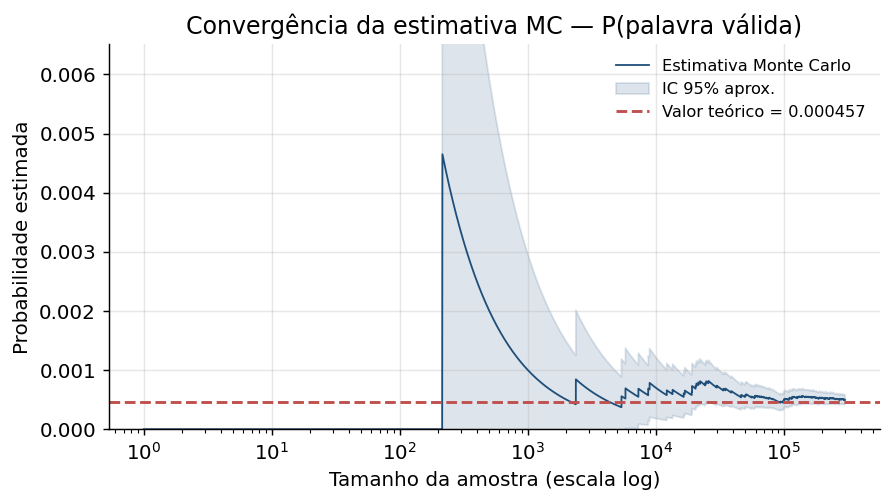

In [10]:
rng = np.random.default_rng(2026)   # Added for reproducibility if previous cells are not run
def gera_uniforme(n, k=5, rng=None):
    """Gera n sequências de k letras i.i.d. uniformes; retorna array de strings."""
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.integers(0, 26, size=(n, k))
    return np.array([''.join(ALFABETO[linha]) for linha in idx])

N    = 300_000
seqs = gera_uniforme(N, rng=rng)
valida = np.fromiter((s in dic5 for s in seqs), dtype=bool, count=N)

p_a_teorico = N_VALIDAS_5 / 26**5          # 0.00045677
p_a_mc      = valida.mean()
print(f"p_a (Monte Carlo) = {p_a_mc:.6f}")
print(f"p_a (analítico)   = {p_a_teorico:.6f}")

n_acum = np.arange(1, N + 1)
estim  = np.cumsum(valida) / n_acum
erro_pad = np.sqrt(estim * (1 - estim) / n_acum)

# ---- Gráfico (idêntico ao relatório) ----
n_acum = np.arange(1, N + 1)
estim  = np.cumsum(valida) / n_acum
erro_pad = np.sqrt(estim * (1 - estim) / n_acum)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_acum, estim, color=C1, lw=1, label="Estimativa Monte Carlo")
ax.fill_between(n_acum, estim-1.96*erro_pad, estim+1.96*erro_pad, color=C1, alpha=.15, label="IC 95% aprox.")
ax.axhline(p_a_teorico, color=C2, ls="--", lw=1.6, label=f"Valor teórico = {p_a_teorico:.6f}")
ax.set_xscale("log")
ax.set_xlabel("Tamanho da amostra (escala log)"); ax.set_ylabel("Probabilidade estimada")
ax.set_title("Convergência da estimativa MC — P(palavra válida)")
ax.legend(frameon=False, fontsize=9)
ax.set_ylim(0, max(estim[100:].max()*1.4, p_a_teorico*2.5))
fig.tight_layout()
fig.savefig("graficos/Q1a_palavra_valida.png", dpi=130, bbox_inches="tight")
plt.show()

### Item (b): Probabilidade de palíndromo

#### Solução analítica

Uma sequência de 5 letras $\ell_1\ell_2\ell_3\ell_4\ell_5$ é um palíndromo quando

$$
\ell_1 = \ell_5
\quad \text{e} \quad
\ell_2 = \ell_4,
$$

enquanto $\ell_3$ é livre.

Fixadas as três primeiras letras, as duas últimas ficam completamente determinadas. Portanto, existem

$$
26^3
$$

palíndromos entre os

$$
26^5
$$

resultados equiprováveis. Assim,

$$
p_b = \frac{26^3}{26^5}
= \frac{1}{26^2}
= \frac{1}{676}
\approx 1,479 \times 10^{-3}.
$$

Note que essa probabilidade independe de a sequência ser ou não uma palavra válida, conforme solicitado no enunciado.

<br>

**Tabela 1.** Probabilidade de gerar uma palavra válida de 5 letras.

| Medida | Probabilidade |
|---------|---------|
| Estimativa Monte Carlo ($N = 300000$) | $4,97 \times 10^{-4}$ |
| Valor analítico exato | $4,568 \times 10^{-4}$ |

<br>

**Tabela 2.** Probabilidade de a sequência ser um palíndromo.

| Medida                                 | Probabilidade          |
| -------------------------------------- | ---------------------- |
| Estimativa Monte Carlo ($N = 300,000$) | $1,477 \times 10^{-3}$ |
| Valor analítico exato ($1/26^2$)       | $1,479 \times 10^{-3}$ |

A estimativa obtida por Monte Carlo praticamente coincide com o valor teórico $1/676$, confirmando o cálculo analítico.



p_b (Monte Carlo) = 0.001477
p_b (analítico)   = 0.001479


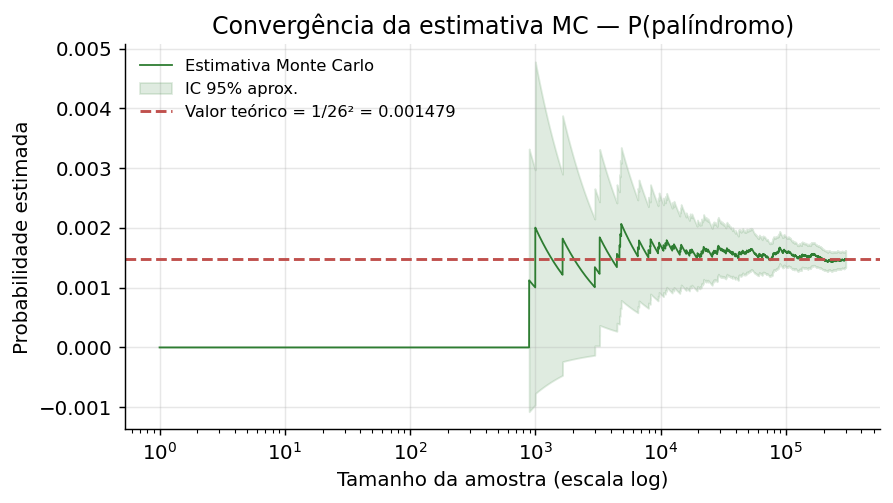

In [ ]:
# Reaproveita as mesmas sequências do item (a) — eficiência computacional
palindromo = np.fromiter((s == s[::-1] for s in seqs), dtype=bool, count=N)
p_b_teorico = 1/26**2          # 0.00147929
p_b_mc      = palindromo.mean()
print(f"p_b (Monte Carlo) = {p_b_mc:.6f}")
print(f"p_b (analítico)   = {p_b_teorico:.6f}")

# ---- Gráfico (idêntico ao relatório) ----
n_acum = np.arange(1, N + 1)
runp   = np.cumsum(palindromo) / n_acum
sep    = np.sqrt(runp*(1-runp)/n_acum)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_acum, runp, color=C3, lw=1, label="Estimativa Monte Carlo")
ax.fill_between(n_acum, runp-1.96*sep, runp+1.96*sep, color=C3, alpha=.15, label="IC 95% aprox.")
ax.axhline(p_b_teorico, color=C2, ls="--", lw=1.6, label=f"Valor teórico = 1/26² = {p_b_teorico:.6f}")
ax.set_xscale("log")
ax.set_xlabel("Tamanho da amostra (escala log)"); ax.set_ylabel("Probabilidade estimada")
ax.set_title("Convergência da estimativa MC — P(palíndromo)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("graficos/Q1b_palindromo.png", dpi=130, bbox_inches="tight")
plt.show()

### 3.3. Item (c): Gerador alternante consoante/vogal

#### Definição do gerador

A primeira letra é escolhida uniformemente entre as 26 letras do alfabeto. A partir daí, alternam-se as classes: após uma vogal (conjunto $V={a,e,i,o,u}$, com $|V|=5$) vem uma consoante (conjunto $C$, com $|C|=21$) e vice-versa, sempre com escolha uniforme dentro da respectiva classe.

Assim, toda sequência gerada segue um de dois padrões:

* $VCVCV$, se a primeira letra é uma vogal;
* $CVCVC$, se a primeira letra é uma consoante.

#### Solução analítica

A probabilidade de uma sequência específica do padrão $VCVCV$ é

$$
\underbrace{\frac{1}{26}}_{\ell_1=\text{vogal}}
\cdot
\frac{1}{21}
\cdot
\frac{1}{5}
\cdot
\frac{1}{21}
\cdot
\frac{1}{5}
=
\frac{1}{26\cdot5^2\cdot21^2},
$$

e a de uma sequência específica $CVCVC$ é

$$
\frac{1}{26}
\cdot
\frac{1}{5}
\cdot
\frac{1}{21}
\cdot
\frac{1}{5}
\cdot
\frac{1}{21}
=
\frac{1}{26\cdot5^2\cdot21^2},
$$

igual à anterior. Ou seja, todas as

$$
26\cdot5^2\cdot21^2 = 286650
$$

sequências geráveis são equiprováveis.

Logo, se $n_{VCVCV}$ e $n_{CVCVC}$ são os números de palavras válidas com cada padrão,

$$
p_c=
\frac{n_{VCVCV}+n_{CVCVC}}
{26\cdot5^2\cdot21^2}.
$$

Varrendo o dicionário, obtemos $n_{VCVCV}=517$ e $n_{CVCVC}=1474$, portanto

$$
p_c=
\frac{517+1474}{286650}
=
\frac{1991}{286650}
\approx
6,95\times10^{-3}.
$$

Logo,

Varrendo o dicionário, obtemos $n_{VCVCV}=517$ e $n_{CVCVC}=1474$, portanto

$$
p_c=\frac{517+1474}{286650}
=\frac{1991}{286650}
\approx 6,95\times10^{-3}.
$$


<br><br>

**Tabela 3.** Probabilidade de gerar uma palavra válida utilizando o gerador alternante consoante/vogal.

| Medida | Probabilidade |
|---------|---------|
| Estimativa Monte Carlo ($N = 300000$) | $6,89 \times 10^{-3}$ |
| Valor analítico exato | $6,95 \times 10^{-3}$ |

<br>

**Interpretação.** A probabilidade de gerar uma palavra válida aumentou de aproximadamente $4,6 \times 10^{-4}$ (item a) para aproximadamente $7,0 \times 10^{-3}$, representando um aumento de cerca de 15 vezes. Ao impor a alternância entre vogais e consoantes, o gerador restringe o espaço amostral a sequências com estrutura fonética mais próxima das palavras reais da língua portuguesa, elevando significativamente a taxa de acerto.



n_VCVCV=517, n_CVCVC=1474
p_c (Monte Carlo) = 0.006930
p_c (analítico)   = 0.006946


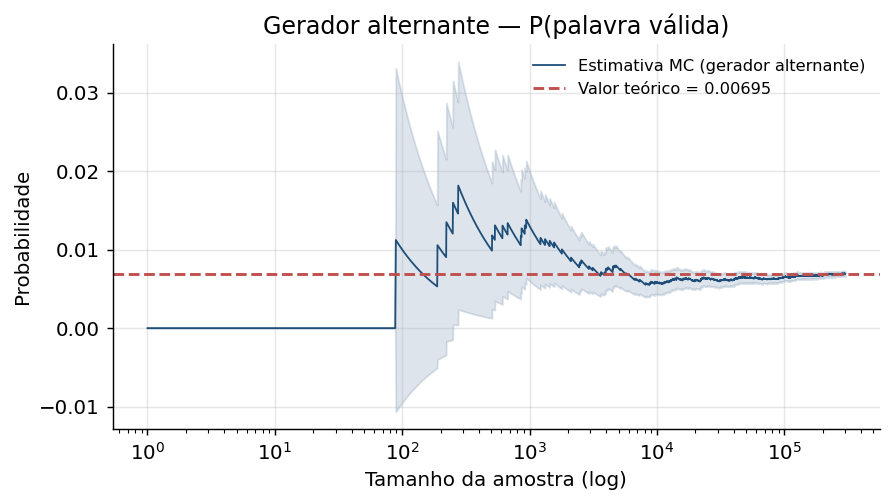

In [ ]:
VOGAIS     = list('aeiou')
CONSOANTES = [c for c in 'abcdefghijklmnopqrstuvwxyz' if c not in VOGAIS]

def padrao(w):
    return ''.join('V' if c in 'aeiou' else 'C' for c in w)

def gera_alternante(n, rng):
    """Primeira letra uniforme no alfabeto; demais alternam V/C."""
    res = np.empty((n, 5), dtype='<U1')
    primeiras = rng.integers(0, 26, n)
    for i, f in enumerate(primeiras):
        c0 = ALFABETO[f]; seq = [c0]; eh_vogal = c0 in 'aeiou'
        for _ in range(4):
            eh_vogal = not eh_vogal
            seq.append(VOGAIS[rng.integers(5)] if eh_vogal
                       else CONSOANTES[rng.integers(21)])
        res[i] = seq
    return np.array([''.join(r) for r in res])

# Contagem analítica
nV = sum(1 for w in dic5 if padrao(w) == 'VCVCV')   # 517
nC = sum(1 for w in dic5 if padrao(w) == 'CVCVC')   # 1474
p_c_teorico = (nV + nC) / (26 * 5**2 * 21**2)        # 0.0069458

g_alt  = gera_alternante(300_000, rng)
p_c_mc = np.mean([s in dic5 for s in g_alt])
print(f"n_VCVCV={nV}, n_CVCVC={nC}")
print(f"p_c (Monte Carlo) = {p_c_mc:.6f}")
print(f"p_c (analítico)   = {p_c_teorico:.6f}")

# ---- Gráfico (idêntico ao relatório) ----
vc   = np.fromiter((s in dic5 for s in g_alt), bool, len(g_alt))
nn   = np.arange(1, len(g_alt) + 1)
runc = np.cumsum(vc) / nn
sec  = np.sqrt(runc*(1-runc)/nn)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(nn, runc, color=C1, lw=1, label="Estimativa MC (gerador alternante)")
ax.fill_between(nn, runc-1.96*sec, runc+1.96*sec, color=C1, alpha=.15)
ax.axhline(p_c_teorico, color=C2, ls="--", lw=1.6, label=f"Valor teórico = {p_c_teorico:.5f}")
ax.set_xscale("log")
ax.set_xlabel("Tamanho da amostra (log)"); ax.set_ylabel("Probabilidade")
ax.set_title("Gerador alternante — P(palavra válida)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("graficos/Q1c_gerador_alternante.png", dpi=130, bbox_inches="tight")
plt.show()

### 3.4. Item (d): Gerador ponderado pela frequência das letras, condicionado a conter “a”

**Modelo.** Cada uma das 5 letras é sorteada de forma independente com probabilidade proporcional à frequência da letra no português (tabela da Wikipédia indicada no enunciado). Denotando por $\pi_\ell$ a frequência normalizada da letra $\ell$ ($\sum_{\ell}\pi_\ell=1$), a probabilidade de gerar uma sequência específica

$$
s=\ell_1\cdots\ell_5
$$

é

$$
\Pr(s)=\prod_{j=1}^{5}\pi_{\ell_j}.
$$

Queremos calcular $\Pr(\text{válida}\mid A)$. Por definição de probabilidade condicional,

$$
\Pr(\text{válida}\mid A)
=
\frac{\Pr(\text{válida}\cap A)}
{\Pr(A)},
\qquad
A=\{\text{a sequência contém ao menos um } a\}.
$$

O denominador é

$$
\Pr(A)
=
1-(1-\pi_a)^5
\approx
0,5465.
$$

O numerador soma $\Pr(s)$ sobre todas as palavras válidas que contêm a letra "a". Avaliando exatamente,

$$
\Pr(\text{válida}\mid A)
=
\frac{0,005559}{0,546514}
\approx
1,017\times10^{-2}.
$$

A resposta analítica é calculável (como mostrado), pois o espaço é finito e as probabilidades são conhecidas, embora envolva percorrer o dicionário e somar produtos de frequências.

<br>

<br>

**Tabela 4.** Probabilidade condicional de gerar uma palavra válida dado que a sequência contém pelo menos uma letra "a".

| Medida | Probabilidade |
|---------|---------|
| Estimativa Monte Carlo ($N = 500000$) | $1,05 \times 10^{-2}$ |
| Valor analítico exato | $1,017 \times 10^{-2}$ |

<br>

<br>

**Tabela 5.** Probabilidade condicional de gerar uma palavra válida dado que a sequência contém pelo menos uma letra "a".

| Medida | Probabilidade |
|---------|---------|
| Estimativa Monte Carlo ($N = 500000$) | $1,05 \times 10^{-2}$ |
| Valor analítico exato | $1,017 \times 10^{-2}$ |

P(válida | tem 'a')  MC        = 0.010289
P(válida | tem 'a')  analítico = 0.010171


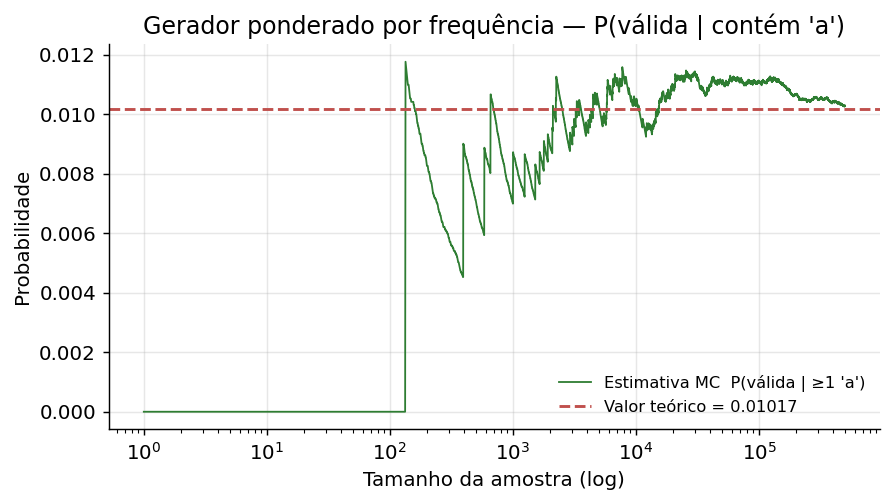

In [ ]:
freq = {'a':14.63,'b':1.04,'c':3.88,'d':4.99,'e':12.57,'f':1.02,'g':1.30,
        'h':1.28,'i':6.18,'j':0.40,'k':0.02,'l':2.78,'m':4.74,'n':5.05,
        'o':10.73,'p':2.52,'q':1.20,'r':6.53,'s':7.81,'t':4.34,'u':4.63,
        'v':1.67,'w':0.01,'x':0.21,'y':0.01,'z':0.47}
prob_letra = np.array([freq[c] for c in ALFABETO])
prob_letra = prob_letra / prob_letra.sum()    # normaliza p/ somar 1

N = 500_000
idx = rng.choice(26, size=(N,5), p=prob_letra)         # sample com prob (== 'prob' do R)
seqs_d = np.array([''.join(ALFABETO[i] for i in linha) for linha in idx])
tem_a    = np.fromiter(('a' in s for s in seqs_d), bool, N)
valida_d = np.fromiter((s in dic5 for s in seqs_d), bool, N)
p_d_mc   = valida_d[tem_a].mean()

def prob_seq(w):
    p = 1.0
    for ch in w: p *= prob_letra[ord(ch)-97]
    return p
num = sum(prob_seq(w) for w in dic5 if 'a' in w)
P_A = 1 - (1-prob_letra[0])**5
p_d_teorico = num / P_A
print(f"P(válida | tem 'a')  MC        = {p_d_mc:.6f}")
print(f"P(válida | tem 'a')  analítico = {p_d_teorico:.6f}")

# ---- Gráfico (idêntico ao relatório) ----
nnd = np.arange(1, N + 1)
cv  = np.cumsum(valida_d & tem_a) / np.maximum(np.cumsum(tem_a), 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(nnd, cv, color=C3, lw=1, label="Estimativa MC  P(válida | ≥1 'a')")
ax.axhline(p_d_teorico, color=C2, ls="--", lw=1.6, label=f"Valor teórico = {p_d_teorico:.5f}")
ax.set_xscale("log")
ax.set_xlabel("Tamanho da amostra (log)"); ax.set_ylabel("Probabilidade")
ax.set_title("Gerador ponderado por frequência — P(válida | contém 'a')")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("graficos/Q1d_ponderado_cond_a.png", dpi=130, bbox_inches="tight")
plt.show()

## Questão 2. Gerando números pseudo-aleatórios

### 2. Item (a): Cauchy pela transformada inversa

**Método.** Para obter a função inversa é necessário determinar a função de distribuição acumulada da função densidade de probabilidade da distribuição Cauchy, dada por

$$
f(x)=
\frac{1}
{\pi\gamma\left[1+\left(\frac{x}{\gamma}\right)^2\right]},
\qquad
-\infty < x < \infty,
\quad
\gamma > 0.
$$

A função distribuição acumulada é dada por

$$
F(x)
=
\int_{-\infty}^{x}
\frac{1}
{\pi\gamma\left[1+\left(\frac{t}{\gamma}\right)^2\right]}
\,dt.
$$

Fazendo a substituição

$$
u=\frac{t}{\gamma},
\qquad
du=\frac{dt}{\gamma}
\;\Rightarrow\;
dt=\gamma\,du,
$$

obtemos

$$
F(x)
=
\frac{1}{\pi\gamma}
\int_{-\infty}^{x/\gamma}
\frac{\gamma}{1+u^2}\,du
=
\frac{1}{\pi}
\int_{-\infty}^{x/\gamma}
\frac{1}{1+u^2}\,du.
$$

Como

$$
\int \frac{1}{1+u^2}\,du
=
\arctan(u),
$$

segue que

$$
F(x)
=
\frac{1}{\pi}
\left[
\arctan(u)
\right]_{-\infty}^{x/\gamma}.
$$

Portanto,

$$
F(x)
=
\frac{1}{\pi}\arctan\!\left(\frac{x}{\gamma}\right)
-
\frac{1}{\pi}
\left(-\frac{\pi}{2}\right)
=
\frac{1}{\pi}\arctan\!\left(\frac{x}{\gamma}\right)
+\frac{1}{2}.
$$

Logo,

$$
F(x)
=
\frac{1}{\pi}\arctan\!\left(\frac{x}{\gamma}\right)
+\frac{1}{2}.
$$

Para obter a inversa, fazemos

$$
u=F(x)
=
\frac{1}{\pi}\arctan\!\left(\frac{x}{\gamma}\right)
+\frac{1}{2}.
$$

Isolando $x$, temos

$$
\frac{1}{\pi}
\arctan\!\left(\frac{x}{\gamma}\right)
=
u-\frac{1}{2},
$$

e, portanto,

$$
\arctan\!\left(\frac{x}{\gamma}\right)
=
\pi\left(u-\frac{1}{2}\right).
$$

Aplicando a função tangente em ambos os lados,

$$
\frac{x}{\gamma}
=
\tan\!\left[
\pi\left(u-\frac{1}{2}\right)
\right].
$$

Assim,

$$
x
=
\gamma
\tan\!\left[
\pi\left(u-\frac{1}{2}\right)
\right].
$$

Logo,

$$
F^{-1}(u)
=
\gamma
\tan\!\left[
\pi\left(u-\frac{1}{2}\right)
\right].
$$

Portanto, se

$$
U \sim U(0,1),
$$

então

$$
X
=
F^{-1}(U)
=
\gamma
\tan\!\left[
\pi\left(U-\frac{1}{2}\right)
\right]
$$

tem distribuição Cauchy com parâmetro $\gamma$.

mediana: 0.002947785823565723 | semi-IQR: 1.0024715237457003


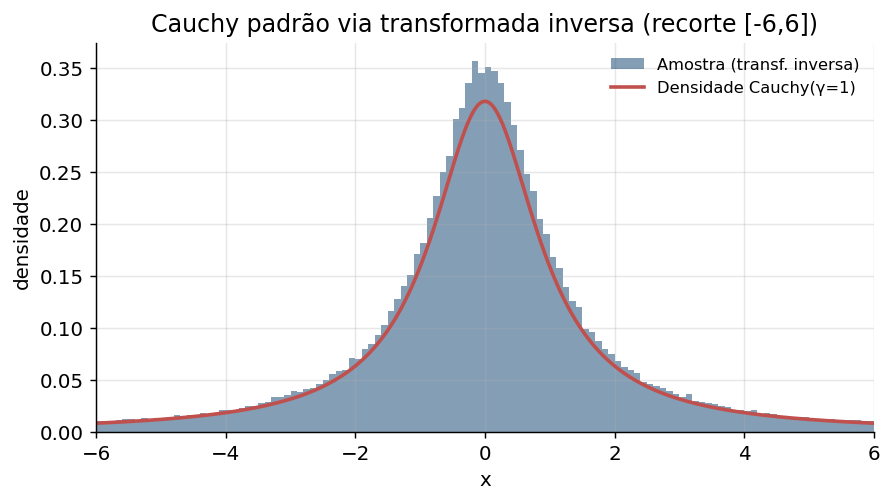

In [ ]:
def rcauchy_inversa(n, gamma=1.0, rng=None):
    """Amostra Cauchy(gamma) pelo método da transformada inversa."""
    rng = np.random.default_rng() if rng is None else rng
    u = rng.uniform(size=n)
    return gamma * np.tan(np.pi * (u - 0.5))

x = rcauchy_inversa(200_000, gamma=1.0, rng=rng)

# ---- Gráfico (idêntico ao relatório) ----
print("mediana:", np.median(x), "| semi-IQR:", (np.percentile(x,75)-np.percentile(x,25))/2)
xc = x[(x > -6) & (x < 6)]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(xc, bins=120, density=True, color=C1, alpha=.55, label="Amostra (transf. inversa)")
t = np.linspace(-6, 6, 400)
ax.plot(t, 1/(np.pi*(1+t**2)), color=C2, lw=2, label="Densidade Cauchy(γ=1)")
ax.set_xlim(-6, 6); ax.set_xlabel("x"); ax.set_ylabel("densidade")
ax.set_title("Cauchy padrão via transformada inversa (recorte [-6,6])")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("graficos/Q2a_cauchy_inversa.png", dpi=130, bbox_inches="tight")
plt.show()

**Figura 5.** Comparação entre o histograma da amostra gerada ($N=200000$, $\gamma=1$) e a densidade teórica da distribuição Cauchy padrão.

**Interpretação.** A Figura 5 compara o histograma de uma amostra de tamanho $200000$ (com $\gamma=1$) à densidade teórica da distribuição Cauchy padrão, evidenciando excelente concordância entre os resultados simulados e o modelo teórico.

Como a distribuição Cauchy não possui média nem variância finitas, a validação não pode ser realizada por meio desses momentos. Em vez disso, foram utilizadas estatísticas robustas, como a mediana e a semiamplitude interquartílica.

A mediana amostral obtida foi aproximadamente igual a $0$, em concordância com o valor teórico da distribuição. Além disso, a semiamplitude interquartílica observada foi aproximadamente igual a $\gamma$, conforme previsto teoricamente. Esses resultados fornecem evidências adicionais da correta implementação do método da transformada inversa para a geração de variáveis aleatórias com distribuição Cauchy.

### 2. Item (b): Variável discreta pela transformada inversa

#### Distribuição

A variável aleatória $X$ assume os valores

$$
\{2,3,5,6,9\}
$$

com probabilidades

$$
\{0,3;\;0,1;\;0,1;\;0,3;\;0,2\}.
$$

A função de distribuição acumulada correspondente é

$$
F(x)=
\{0,3;\;0,4;\;0,5;\;0,8;\;1,0\}.
$$

No método da transformada inversa para variáveis discretas, sorteia-se

$$
U \sim \text{Unif}(0,1)
$$

e retorna-se o menor valor $x_j$ tal que

$$
F(x_j)\ge U.
$$

Equivalentemente,

$$
X=
\begin{cases}
2, & 0 \le U < 0,3,\\[4pt]
3, & 0,3 \le U < 0,4,\\[4pt]
5, & 0,4 \le U < 0,5,\\[4pt]
6, & 0,5 \le U < 0,8,\\[4pt]
9, & 0,8 \le U \le 1.
\end{cases}
$$

Dessa forma, cada valor é gerado com a probabilidade especificada pela distribuição original.

<br>

<br>

**Tabela 6.** Frequências relativas empíricas ($n=1000$) versus probabilidades teóricas.

| $x$ | Teórica | Empírica (inversa) | Empírica (sample) |
|:---:|:--------:|:------------------:|:-----------------:|
| 2 | 0,30 | 0,313 | 0,312 |
| 3 | 0,10 | 0,101 | 0,102 |
| 5 | 0,10 | 0,107 | 0,099 |
| 6 | 0,30 | 0,308 | 0,288 |
| 9 | 0,20 | 0,171 | 0,199 |

x  teórica  inversa  sample
2   0.30    0.282    0.299
3   0.10    0.117    0.114
5   0.10    0.092    0.104
6   0.30    0.296    0.295
9   0.20    0.213    0.188


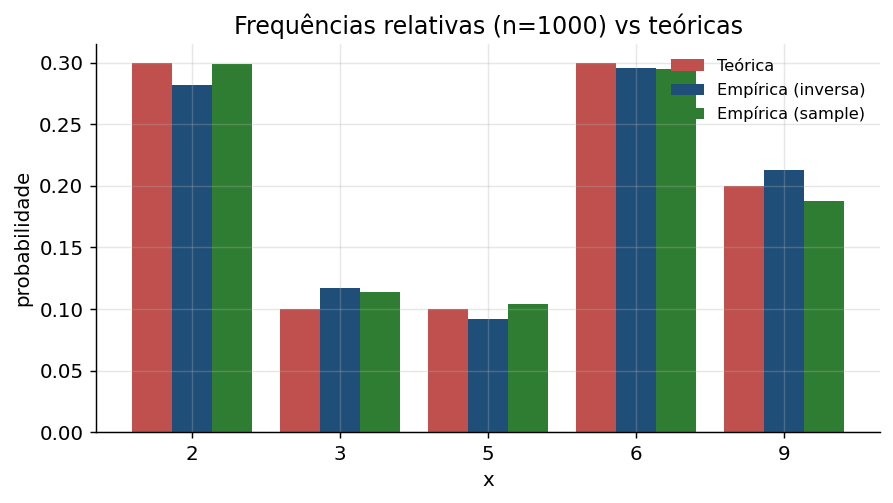

In [ ]:
valores = np.array([2, 3, 5, 6, 9])
probs   = np.array([0.3, 0.1, 0.1, 0.3, 0.2])
F_acum  = np.cumsum(probs)                       # [0.3,0.4,0.5,0.8,1.0]

def amostra_inversa_discreta(n, rng):
    u = rng.uniform(size=n)
    return valores[np.searchsorted(F_acum, u)]   # transformada inversa

n = 1000
amostra1 = amostra_inversa_discreta(n, rng)      # método da inversa
amostra2 = rng.choice(valores, size=n, p=probs)  # equivalente ao sample() do R

freq_rel1 = np.array([(amostra1 == v).mean() for v in valores])
freq_rel2 = np.array([(amostra2 == v).mean() for v in valores])
print("x  teórica  inversa  sample")
for v,p,e1,e2 in zip(valores,probs,freq_rel1,freq_rel2):
    print(f"{v}   {p:.2f}    {e1:.3f}    {e2:.3f}")

# ---- Gráfico (idêntico ao relatório) ----
fig, ax = plt.subplots(figsize=(7, 4))
w = 0.27; xp = np.arange(len(valores))
ax.bar(xp-w, probs, w, label="Teórica", color=C2)
ax.bar(xp,   freq_rel1, w, label="Empírica (inversa)", color=C1)
ax.bar(xp+w, freq_rel2, w, label="Empírica (sample)", color=C3)
ax.set_xticks(xp); ax.set_xticklabels(valores); ax.set_xlabel("x"); ax.set_ylabel("probabilidade")
ax.set_title("Frequências relativas (n=1000) vs teóricas")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("graficos/Q2b_discreta_inversa.png", dpi=130, bbox_inches="tight")
plt.show()

**Interpretação.** Ambos os métodos reproduzem adequadamente a distribuição teórica. As pequenas discrepâncias observadas entre as frequências empíricas e as probabilidades teóricas são compatíveis com a variabilidade amostral esperada para uma amostra de tamanho $n=1000$.

De fato, o desvio-padrão da estimativa de uma proporção é dado por

$$
\sqrt{\frac{p(1-p)}{n}},
$$

que, para os valores de $p$ considerados, é da ordem de

$$
\sqrt{\frac{p(1-p)}{1000}}
\approx 0,014.
$$

Assim, as diferenças observadas são consistentes com flutuações amostrais aleatórias e confirmam que tanto o método da transformada inversa quanto a função `sample()` reproduzem corretamente a distribuição especificada.

### 2. Item (c): Normal padrão por aceitação-rejeição (candidato Cauchy)

#### Método

No método de aceitação-rejeição é necessário obter a constante de rejeição

$$
M=\sup_x \frac{f(x)}{g(x)},
$$

onde $f(x)$ é a densidade alvo (Normal Padrão) e $g(x)$ é a densidade proposta (Cauchy Padrão).

Como

$$
f(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}
$$

e

$$
g(x)=\frac{1}{\pi(1+x^2)},
$$

tem-se

$$
M
=
\sup_x
\frac{\frac{1}{\sqrt{2\pi}}e^{-x^2/2}}
{\frac{1}{\pi(1+x^2)}}
=
\sqrt{\frac{\pi}{2}}
(1+x^2)e^{-x^2/2}
=
h(x).
$$

Encontrar o máximo de $h(x)$ equivale a maximizar

$$
w(x)=(1+x^2)e^{-x^2/2}.
$$

A primeira derivada é

$$
w'(x)
=
2xe^{-x^2/2}
+
(1+x^2)(-xe^{-x^2/2}),
$$

ou

$$
w'(x)
=
xe^{-x^2/2}
\left[
2-(1+x^2)
\right].
$$

Logo,

$$
w'(x)
=
xe^{-x^2/2}(1-x^2).
$$

Igualando a zero,

$$
xe^{-x^2/2}(1-x^2)=0,
$$

obtêm-se os pontos críticos

$$
x_1=0,
\qquad
x_2=1,
\qquad
x_3=-1.
$$

Como $e^{-x^2/2}>0$,

- para $x=0$:

$$
(1+0)e^0=1;
$$

- para $x=1$:

$$
(1+1)e^{-1/2}
=
2e^{-1/2},
$$

que corresponde ao máximo.

Portanto,

$$
M
=
\sqrt{\frac{\pi}{2}}
\,2e^{-1/2}
=
\sqrt{\frac{2\pi}{e}}
\approx 1,5203.
$$

O algoritmo gera um candidato $Y\sim g$ (Cauchy, via item (a)) e $U\sim\text{Unif}(0,1)$, aceitando $Y$ se

$$
U
\le
\frac{f(Y)}
{M\,g(Y)}.
$$

A taxa teórica de aceitação é

$$
\frac{1}{M}
=
\sqrt{\frac{e}{2\pi}}
\approx 0,6577.
$$

<br>

**Tabela 7.** Diagnósticos do gerador de Normal padrão.

| Medida | Empírica | Teórica |
|:--------|:--------:|:--------:|
| Média | $-0,0003$ | $0$ |
| Desvio-padrão | $1,0021$ | $1$ |
| Taxa de aceitação | $0,659$ | $0,658\,(=1/M)$ |
| Constante $M$ | $1,5203$ | — |

<br>

**Interpretação.**

O histograma da amostra gerada apresenta excelente aderência à curva da distribuição Normal padrão. Além disso, os momentos empíricos obtidos são praticamente idênticos aos valores teóricos, com média próxima de $0$ e desvio-padrão próximo de $1$.

A taxa de aceitação observada ($\approx 0,66$) também está em concordância com a taxa teórica esperada,

$$
\frac{1}{M}
=
\sqrt{\frac{e}{2\pi}}
\approx 0,658,
$$

confirmando a correção do valor calculado para a constante de rejeição

$$
M=\sqrt{\frac{2\pi}{e}}
\approx 1,5203.
$$

Isso indica que o algoritmo de aceitação-rejeição é eficiente neste contexto: aproximadamente um terço dos candidatos gerados é rejeitado, um custo computacional relativamente baixo decorrente do fato de a distribuição Cauchy possuir caudas mais pesadas que a Normal, condição necessária para garantir a dominância $Mg(x)\geq f(x)$ para todo $x$.

M=1.5203 | média=-0.0023 | sd=0.9993


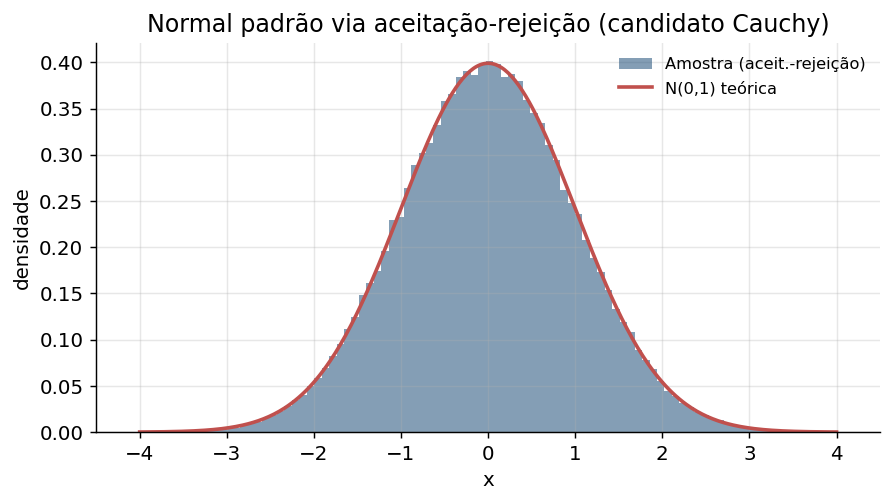

In [ ]:
def rnorm_aceitacao_rejeicao(n, rng):
    """Gera N(0,1) por aceitação-rejeição usando candidato Cauchy padrão."""
    M = np.sqrt(np.pi/2) * 2 * np.exp(-0.5)     # constante de cobertura
    aceitos = []
    while len(aceitos) < n:
        m = n - len(aceitos)
        y = rcauchy_inversa(m, gamma=1.0, rng=rng)        # candidato g ~ Cauchy
        u = rng.uniform(size=m)
        f = (1/np.sqrt(2*np.pi))*np.exp(-y**2/2)         # alvo  f ~ N(0,1)
        g = 1/(np.pi*(1+y**2))                           # proposta g
        aceitos.extend(y[u <= f/(M*g)].tolist())            # critério de aceitação
    return np.array(aceitos[:n])

# ---- Gráfico (idêntico ao relatório) ----
M = np.sqrt(np.pi/2) * 2 * np.exp(-0.5)          # constante de cobertura (sup f/g)
amostra_normal = rnorm_aceitacao_rejeicao(200_000, rng)
print(f"M={M:.4f} | média={amostra_normal.mean():.4f} | sd={amostra_normal.std():.4f}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(amostra_normal, bins=100, density=True, color=C1, alpha=.55, label="Amostra (aceit.-rejeição)")
t = np.linspace(-4, 4, 400)
ax.plot(t, 1/np.sqrt(2*np.pi)*np.exp(-t**2/2), color=C2, lw=2, label="N(0,1) teórica")
ax.set_xlim(-4.5, 4.5); ax.set_xlabel("x"); ax.set_ylabel("densidade")
ax.set_title("Normal padrão via aceitação-rejeição (candidato Cauchy)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("graficos/Q2c_normal_aceit_rejeicao.png", dpi=130, bbox_inches="tight")
plt.show()